# 10-bcr-influenza-clonotype-analysis

In [1]:
import scanpy as sc
import scirpy as ir
import numpy as np
import json
from pathlib import Path
import pandas as pd
import muon as mu
import anndata as ad
import tarfile
import re
import warnings
warnings.filterwarnings('ignore')

DATA = Path("data")

/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
Matplotlib is building the font cache; this may take a moment.
/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
metadata = pd.read_csv(DATA / "metadata.csv", dtype={"patient": str}).set_index("patient")
metadata

,sex,age,ethnicity,race
patient,,,,
09,female,25,Not Hispanic or Latino,white
15,male,29,Hispanic or Latino,white
48,male,85,Not Hispanic or Latino,white
67,female,28,Not Hispanic or Latino,white
93,female,92,Not Hispanic or Latino,white
94,female,66,Not Hispanic or Latino,white


In [3]:
def extract_tar(tar_path: Path, dest: Path) -> Path:
  if not dest.exists():
    with tarfile.open(tar_path, "r:gz") as tf:
      tf.extractall(dest)
  return dest

def read_sample(path: Path) -> tuple[ad.AnnData, ad.AnnData]:
  cellranger_tar = next(path.glob("*_cellranger.tar.gz"))
  bcrvdj_tar = next(path.glob("*_BCRVDJ.tar.gz"))

  cellranger_dir = extract_tar(cellranger_tar, path / "cellranger")
  bcrvdj_dir = extract_tar(bcrvdj_tar, path / "BCRVDJ")
  contig_csv = next(bcrvdj_dir.glob("**/filtered_contig_annotations.csv"))

  adata_gex = sc.read_10x_mtx(cellranger_dir, var_names="gene_symbols", compressed=False)
  adata_gex.var_names_make_unique()

  adata_tcr = ir.io.read_10x_vdj(contig_csv)
  ir.pp.index_chains(adata_tcr)
  ir.tl.chain_qc(adata_tcr)

  return adata_gex, adata_tcr

def add_metadata(mdata: mu.MuData):
  cell_samples = mdata.obs_names.to_series().str.split("_", expand=True)[1]
  cell_patient = cell_samples.str.split("-", expand=True)[0]

  mdata.obs["sample"] = cell_samples
  mdata.obs["patient"] = cell_patient
  mdata.obs["days_after_vaccination"] = cell_samples.str.split("-", expand=True)[1].astype(int)
  mdata.obs["age"] = cell_patient.map(metadata["age"])
  mdata.obs["sex"] = cell_patient.map(metadata["sex"])
  mdata.obs["young"] = mdata.obs["age"] < 40
  mdata.push_obs()

In [4]:
adatas_gex = {}
adatas_tcr = {}

for sample_dir in sorted(DATA.iterdir()):
  match = re.match(r"(\d+)-(\d+)", sample_dir.name)

  if not sample_dir.is_dir() or not match:
      continue

  sample = sample_dir.name
  gex, tcr = read_sample(sample_dir)

  adatas_gex[sample] = gex
  adatas_tcr[sample] = tcr

adata_gex = ad.concat(adatas_gex, index_unique="_")
adata_tcr = ad.concat(adatas_tcr, index_unique="_")

mdata = mu.MuData({"gex": adata_gex, "airr": adata_tcr})
add_metadata(mdata)
mdata

MuData object with n_obs × n_vars = 140699 × 33538
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	123693 × 33538
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
      layers:	None
    airr:	121533 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [5]:
adata = mdata['gex']
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
mdata

MuData object with n_obs × n_vars = 140699 × 33538
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	123693 × 33538
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      layers:	None
    airr:	121533 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

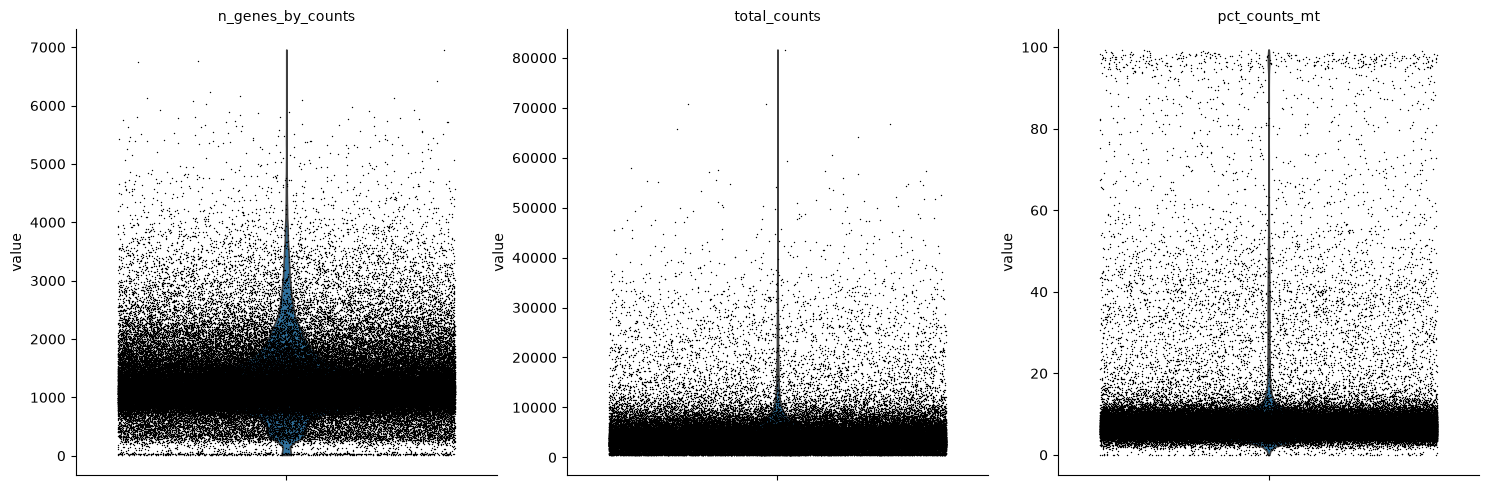

In [6]:
sc.pl.violin(
  mdata['gex'],
  ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
  jitter=0.4,
  multi_panel=True,
)

In [7]:
sc.pp.filter_cells(mdata['gex'], min_genes=200)
sc.pp.filter_genes(mdata['gex'], min_cells=3)
mu.pp.filter_obs(mdata['gex'], 'pct_counts_mt', lambda x: x < 15)
mdata.update()
mu.pp.intersect_obs(mdata)

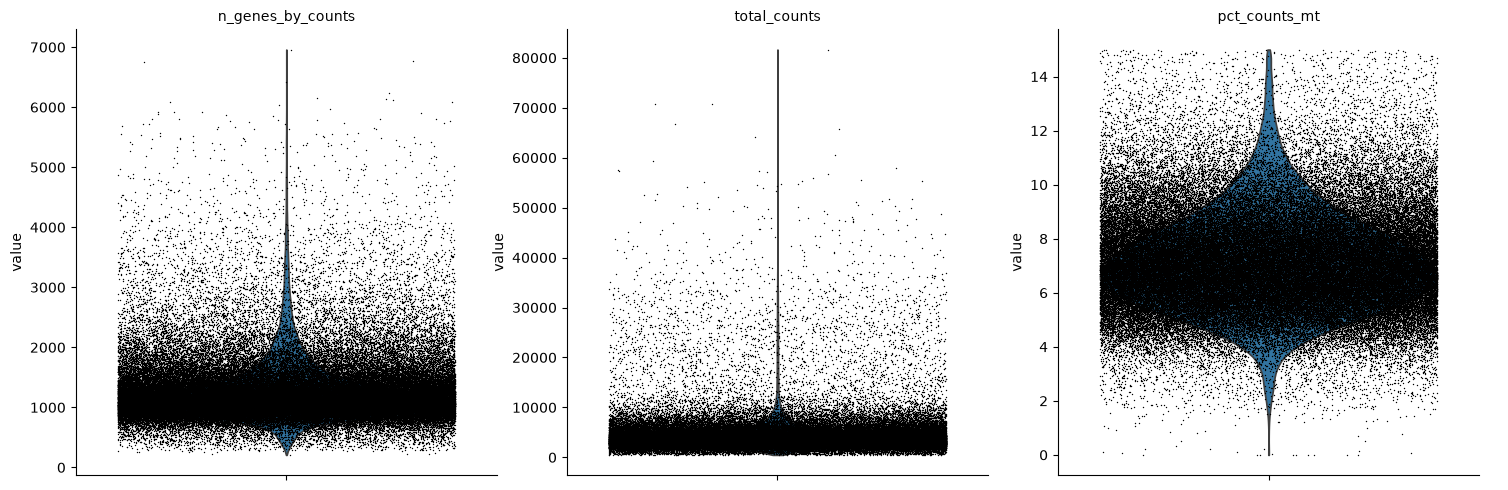

MuData object with n_obs × n_vars = 103150 × 22382
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	103150 × 22382
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      layers:	None
    airr:	103150 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [8]:
sc.pl.violin(
  mdata['gex'],
  ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
  jitter=0.4,
  multi_panel=True,
)
mdata

In [9]:
mu.pp.filter_obs(mdata, "airr:receptor_subtype", lambda x: ~np.isin(x, ["multichain", "ambiguous", "no IR"]))
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: x == "single pair")
mdata.update()
mu.pp.intersect_obs(mdata)
mdata

MuData object with n_obs × n_vars = 77874 × 22382
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	77874 × 22382
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      layers:	None
    airr:	77874 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [10]:
mdata

MuData object with n_obs × n_vars = 77874 × 22382
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	77874 × 22382
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      layers:	None
    airr:	77874 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [11]:
n_cells_after_qc = mdata.obs.shape[0]

print(f"Number of cells after QC: {n_cells_after_qc}")

Number of cells after QC: 77874


In [12]:
ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")
ir.tl.clonotype_network(mdata, min_cells=2)

In [13]:
obs = mdata['airr'].obs
n_clonotypes = obs['clone_id'].unique().shape[0]
max_clonotype = obs['clone_id_size'].max().item()

print(f"Number of clonotypes: {n_clonotypes}")
print(f"Largest clonotype: {max_clonotype}")

Number of clonotypes: 76007
Largest clonotype: 32


In [14]:
output = {
  'n_cells_after_qc': n_cells_after_qc,
  'n_clonotypes': n_clonotypes,
  'max_clonotype': max_clonotype
}

print(json.dumps(output, indent=2))

# with open('output.json', 'w') as f:
#     json.dump(output, f, indent=2)
# print('Results saved to output.json:')

{
  "n_cells_after_qc": 77874,
  "n_clonotypes": 76007,
  "max_clonotype": 32
}
